# Домашнє завдання: Прогнозування орендної плати за житло

## Мета завдання
Застосувати знання з лекції для побудови моделі лінійної регресії, що прогнозує орендну плату за житло в Індії. Ви пройдете весь цикл вирішення задачі машинного навчання: від дослідницького аналізу до оцінки якості моделі.

## Опис датасету
**House Rent Prediction Dataset** містить інформацію про 4700+ оголошень про оренду житла в Індії з такими параметрами:
- **BHK**: Кількість спалень, залів, кухонь
- **Rent**: Орендна плата (цільова змінна)
- **Size**: Площа в квадратних футах
- **Floor**: Поверх та загальна кількість поверхів
- **Area Type**: Тип розрахунку площі
- **Area Locality**: Район
- **City**: Місто
- **Furnishing Status**: Стан меблювання
- **Tenant Preferred**: Тип орендаря
- **Bathroom**: Кількість ванних кімнат
- **Point of Contact**: Контактна особа

---

## Завдання 1: Завантаження та перший огляд даних (1 бал)

**Що потрібно зробити:**
1. Завантажте дані з файлу `House_Rent_Dataset.csv`
2. Виведіть розмір датасету
3. Покажіть перші 5 рядків
4. Виведіть загальну інформацію про дані (включно з типами даних та кількістю значень)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
! ls drive/MyDrive/Files/House_Rent_Dataset.csv

drive/MyDrive/Files/House_Rent_Dataset.csv


In [ ]:
import pandas as pd

# 1. Завантаження даних
df = pd.read_csv('drive/MyDrive/Files/House_Rent_Dataset.csv')

In [ ]:
# 2. Виведення розміру датасету
print(f"Розмір датасету: {df.shape[0]} рядків та {df.shape[1]} стовпців\n")

Розмір датасету: 4746 рядків та 12 стовпців



In [ ]:
# 3. Перші 5 рядків
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [ ]:
# 4. Загальна інформація про дані

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


## Завдання 2: Дослідницький аналіз даних (EDA) (5 балів)

**Що потрібно зробити:**
1. **Аналіз пропущених значень.** Перевірте наявність і відсоток пропущених значень у кожній колонці
2. **Базова статистика.** Обчисліть базову статистику (середнє, квартилі, стандартне відхилення) для числових змінних.
3. **Аналіз цільової змінної.** Побудуйте гістограму розподілу цільової змінної (Rent)
4. **Робота з викидами.** Знайдіть та видаліть викиди в цільовій змінній (якщо є). Визначити викиди можна будь-яким зрозумілим для вас способом, як варіант - таким, що використовується в побудові box-plot (https://en.wikipedia.org/wiki/Box_plot#Example_with_outliers).
5. **Аналіз категоріальних змінних.** Виведіть кількість унікальних значень для кожної з категоріальних колонок.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Аналіз пропущених значень
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
print("Пропущені значення (%):\n", missing_percent)

Пропущені значення (%):
 Posted On            0.0
BHK                  0.0
Rent                 0.0
Size                 0.0
Floor                0.0
Area Type            0.0
Area Locality        0.0
City                 0.0
Furnishing Status    0.0
Tenant Preferred     0.0
Bathroom             0.0
Point of Contact     0.0
dtype: float64


In [ ]:
# 2. Базова статистика
print("\nБазова статистика для числових змінних:")
display(df.describe())


Базова статистика для числових змінних:


,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


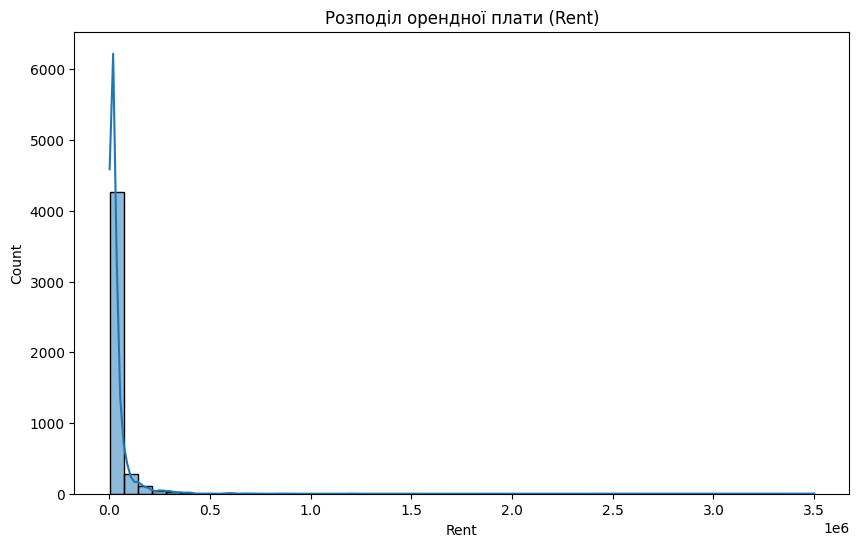

In [ ]:
# 3. Аналіз цільової змінної (Rent)
plt.figure(figsize=(10, 6))
sns.histplot(df['Rent'], bins=50, kde=True)
plt.title('Розподіл орендної плати (Rent)')
plt.show()

In [ ]:
# 4. Робота з викидами (Метод Міжквартильного розмаху - IQR)
Q1 = df['Rent'].quantile(0.25)
Q3 = df['Rent'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Фільтрація датасету від викидів
df_clean = df[(df['Rent'] >= lower_bound) & (df['Rent'] <= upper_bound)]
print(f"\nВидалено рядків: {len(df) - len(df_clean)}")


Видалено рядків: 520


In [ ]:
# 5. Аналіз категоріальних змінних
categorical_cols = df.select_dtypes(include=['object']).columns
print("\nУнікальні значення в категоріальних колонках:")
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} унікальних значень")



Унікальні значення в категоріальних колонках:
Posted On: 81 унікальних значень
Floor: 480 унікальних значень
Area Type: 3 унікальних значень
Area Locality: 2235 унікальних значень
City: 6 унікальних значень
Furnishing Status: 3 унікальних значень
Tenant Preferred: 3 унікальних значень
Point of Contact: 3 унікальних значень



## Завдання 3: Аналіз кореляцій та взаємозв'язків (3 бали)

**Що потрібно зробити:**
1. Обчисліть матрицю кореляцій для числових змінних
2. Візуалізуйте кореляційну матрицю за допомогою heatmap
3. Побудуйте scatter plot між Size та Rent
4. Проаналізуйте взаємозв'язок між BHK та Rent за допомогою boxplot (який розподіл плати для різних значень BHK)


In [ ]:
# 1. Матриця кореляцій (тільки для числових змінних)
# Вибираємо лише числові типи, щоб уникнути помилок
numeric_df = df_clean.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_df.corr()
print("Матриця кореляцій:\n", corr_matrix)


Матриця кореляцій:
                BHK      Rent      Size  Bathroom
BHK       1.000000  0.401268  0.698453  0.747918
Rent      0.401268  1.000000  0.393605  0.506528
Size      0.698453  0.393605  1.000000  0.680607
Bathroom  0.747918  0.506528  0.680607  1.000000


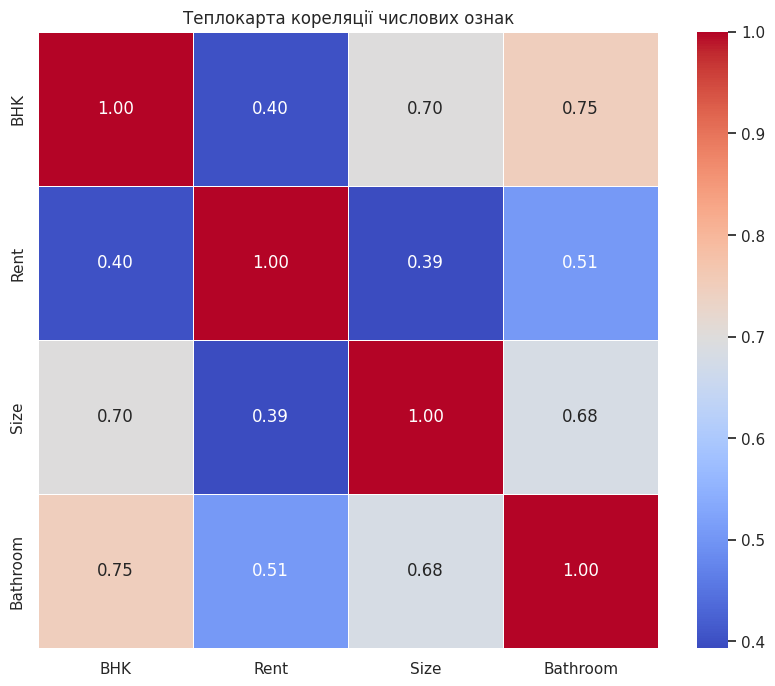

In [ ]:
# 2. Візуалізація Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Теплокарта кореляції числових ознак')
plt.show()


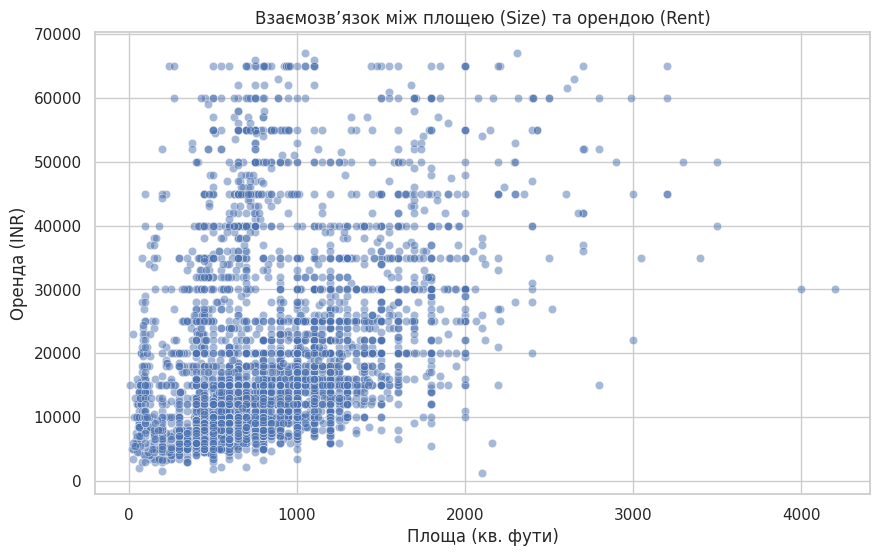

In [ ]:
# 3. Scatter plot між Size та Rent
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='Size', y='Rent', alpha=0.5)
plt.title('Взаємозв’язок між площею (Size) та орендою (Rent)')
plt.xlabel('Площа (кв. фути)')
plt.ylabel('Оренда (INR)')
plt.show()

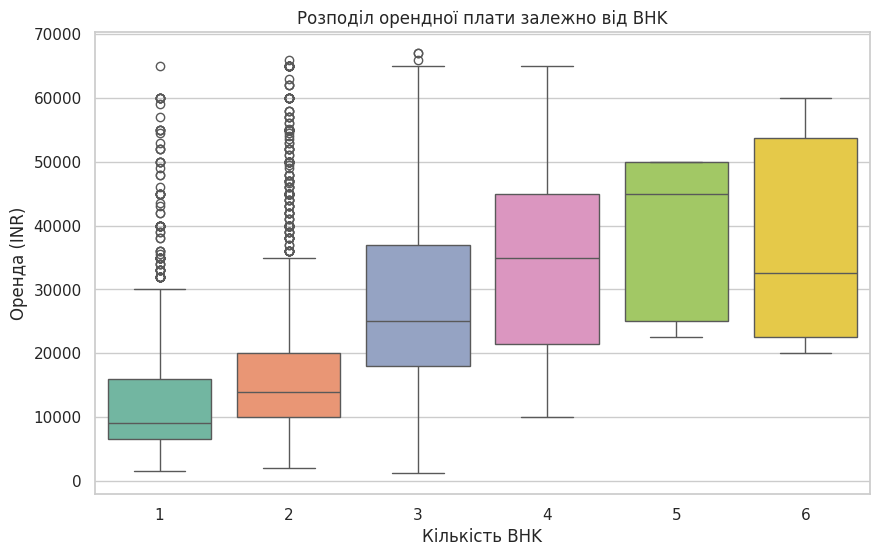

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='BHK', y='Rent', hue='BHK', palette='Set2', legend=False)

plt.title('Розподіл орендної плати залежно від BHK')
plt.xlabel('Кількість BHK')
plt.ylabel('Оренда (INR)')
plt.show()


## Завдання 4: Feature Engineering та підготовка даних (4 бали)

**Що потрібно зробити:**
1. Закодуйте категоріальні змінні за допомогою One-Hot Encoding. Пригадайте, що в лекції ми говорили щодо кодування кат. змінних з великої кількістю різних значень і як працювати з такими випадками. Ви можете закодувати не всі кат. змінні, а лише ті, що вважаєте за потрібні (скажімо ті, що мають відносно небагато різних значень).
2. **Опціонально (по 0.5 бала за кожну доцільну ознаку):** Додайте нові ознаки, обчислені на основі наявних даних, які б на ваш погляд були корисними для моделі
3. Виберіть ознаки для побудови моделі (виключіть непотрібні колонки). Виключити можна, наприклад, ті колонки, які мають категоріальний тип і забагато (більше 20) різних значень. Треба виключити хоча б 1 колонку.
4. Розділіть дані на ознаки (X) та цільову змінну (y)
5. Застосуйте стандартизацію до числових ознак


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Підготовка даних (використовуємо копію)
df_model = df_clean.copy()

# 2. Перетворення числових ознак у float, щоб уникнути конфлікту типів
numeric_cols = ['BHK', 'Size', 'Bathroom', 'Floor_Level', 'Total_Floors']
df_model[numeric_cols] = df_model[numeric_cols].astype(float)

# 3. Вибір ознак (X) та цілі (y)
cols_to_drop = ['Rent', 'Area Locality', 'Floor', 'Point of Contact']
X = df_model.drop(columns=cols_to_drop)
y = df_model['Rent']

# 4. One-Hot Encoding
X = pd.get_dummies(X, columns=['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred'], drop_first=True)

# 5. Розподіл на вибірки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Стандартизація без попереджень
scaler = StandardScaler()
X_train.loc[:, numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test.loc[:, numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Підготовка завершена успішно без попереджень!")
print(f"Форма X_train: {X_train.shape}")



Підготовка завершена успішно без попереджень!
Форма X_train: (3380, 17)


## Завдання 5: Розділення даних та навчання моделі (3 бали)

**Що потрібно зробити:**
1. Розділіть дані на навчальну (80%) та тестову (20%) вибірки.
2. Створіть модель лінійної регресії.
3. Навчіть модель на навчальних даних.
4. Виведіть усі коефіцієнти моделі (ваги) та напишіть, які 2 ознаки найбільше впливають на прогноз.
5. Зробіть прогнози на тренувальній та тестовій вибірках.

In [ ]:
# Повертаємося до кроку підготовки ознак
# Видаляємо дату 'Posted On' та інші непотрібні текстові колонки
cols_to_drop = ['Rent', 'Area Locality', 'Floor', 'Point of Contact']

# Перевіряємо, чи є в датасеті колонка 'Posted On' і додаємо її до списку на видалення
if 'Posted On' in df_model.columns:
    cols_to_drop.append('Posted On')

X = df_model.drop(columns=cols_to_drop)
y = df_model['Rent']

# Кодуємо категоріальні ознаки (One-Hot Encoding)
X = pd.get_dummies(X, columns=['Area Type', 'City', 'Furnishing Status', 'Tenant Preferred'], drop_first=True)

# ВАЖЛИВО: Переконуємося, що в X залишилися ТІЛЬКИ числові дані (float/int/bool)
X = X.select_dtypes(exclude=['object'])

# Розділяємо дані
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Навчаємо модель знову
model = LinearRegression()
model.fit(X_train, y_train)

# Тепер виводимо коефіцієнти
coefficients = pd.DataFrame({
    'Ознака': X_train.columns,
    'Вага': model.coef_
}).sort_values(by='Вага', ascending=False)

print("Топ-2 ознаки за впливом:")
display(coefficients.reindex(coefficients['Вага'].abs().sort_values(ascending=False).index).head(2))


Топ-2 ознаки за впливом:


,Ознака,Вага
11,City_Mumbai,18816.957808
13,Furnishing Status_Unfurnished,-4641.587688


## Завдання 6: Оцінка якості моделі (2 бали)

**Що потрібно зробити:**
1. Обчисліть MAE, RMSE та R² для навчальної та тестової вибірок
2. Порівняйте метрики та зробіть висновок про якість моделі
3. Проаналізуйте і дайте висновок, чи є ознаки перенавчання або недонавчання (**Нагадування**: перенавчання - коли модель дуже добре працює на тренувальних даних, але погано на тестових; недонавчання - коли модель погано працює навіть на тренувальних даних)
4. Побудуйте графік розсіювання "реальні vs прогнозовані значення" та зробіть висновок про якість моделі


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

#  Робимо прогнози (якщо вони не були збережені раніше)
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

# Функція для розрахунку метрик
def get_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {'Вибірка': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'R2': round(r2, 4)}

# Обчислюємо метрики для обох вибірок
metrics_train = get_metrics(y_train, y_train_pred, "Навчальна (80%)")
metrics_test = get_metrics(y_test, y_test_pred, "Тестова (20%)")

# Виводимо таблицю результатів
results = pd.DataFrame([metrics_train, metrics_test])
print("Результати оцінки моделі:")
display(results)



Результати оцінки моделі:


,Вибірка,MAE,RMSE,R2
0,Навчальна (80%),5774.47,8013.61,0.6636
1,Тестова (20%),5606.78,7827.91,0.6804


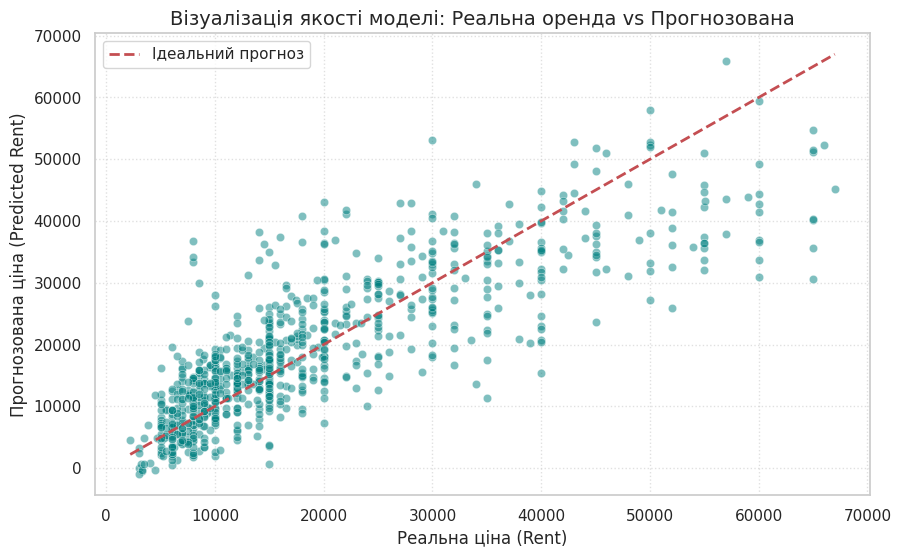

In [ ]:
#  Графік "Реальні vs Прогнозовані значення"
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_test_pred, alpha=0.5, color='teal')

# Лінія ідеального прогнозу
line_coords = [y_test.min(), y_test.max()]
plt.plot(line_coords, line_coords, '--r', lw=2, label='Ідеальний прогноз')

plt.title('Візуалізація якості моделі: Реальна оренда vs Прогнозована', fontsize=14)
plt.xlabel('Реальна ціна (Rent)', fontsize=12)
plt.ylabel('Прогнозована ціна (Predicted Rent)', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()


***Висновок:***

**1.Якість моделі:**

Модель демонструє помірну точність. Точки групуються навколо лінії ідеального прогнозу, що підтверджує наявність лінійної залежності, проте спостерігається значна дисперсія (розкид) прогнозів.

**2.Аналіз прогнозів:**

Модель найкраще працює для бюджетного житла (до 20000-50000). Для дорожчих об'єктів точність падає, і модель частіше занижує реальну вартість оренди.
Загальний підсумок: Побудована модель лінійної регресії придатна для базової оцінки ринку, але для точних прогнозів варто спробувати складніші алгоритми.

## Завдання 7: Аналіз помилок (4 бали)

**Що потрібно зробити:**
1. Обчисліть помилки (residuals = реальні - прогнозовані значення)
2. Побудуйте гістограму розподілу помилок
3. Створіть scatter plot помилок відносно величини прогнозованих значень. Чи росте помилка з ростом прогнозованого значення?
4. Знайдіть 5 прогнозів з найбільшими помилками
5. Проаналізуйте, на яких типах житла модель помиляється найбільше. Типи можна розрізняти за кількістю кімнат чи містом, наприклад.
6. Подумайте і напишіть, які наступні кроки ви б зробили, аби поліпшити якість моделі. Опціонально можна їх зробити і ми перевіримо :)

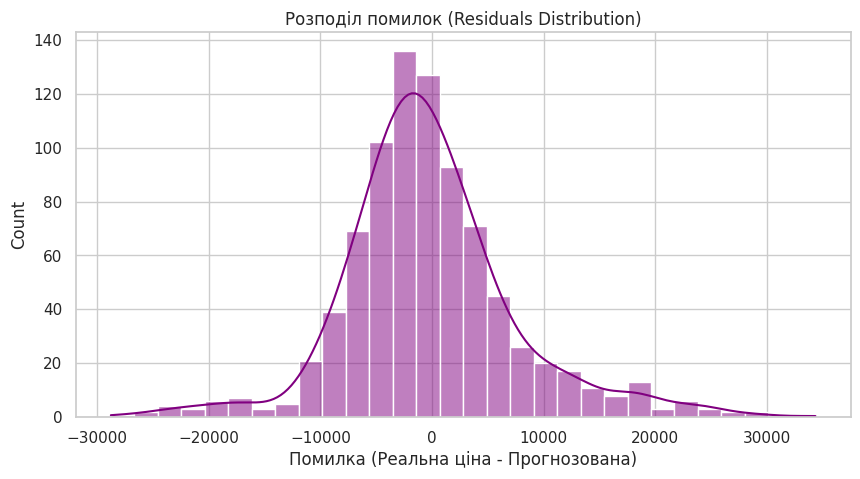

In [ ]:
# 1. Обчислення помилок (залишків)
residuals = y_test - y_test_pred

# 2. Гістограма розподілу помилок
plt.figure(figsize=(10, 5))
sns.histplot(residuals, bins=30, kde=True, color='purple')
plt.title('Розподіл помилок (Residuals Distribution)')
plt.xlabel('Помилка (Реальна ціна - Прогнозована)')
plt.show()


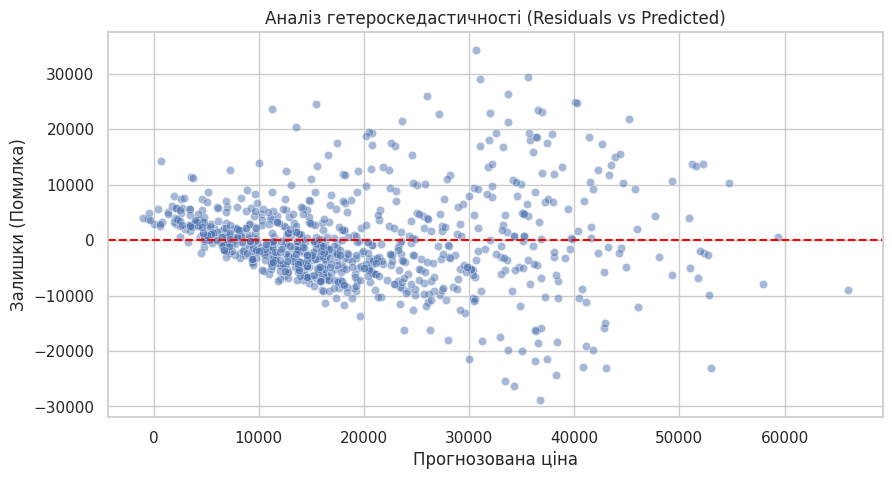

In [ ]:
# 3. Scatter plot помилок відносно прогнозу
plt.figure(figsize=(10, 5))
sns.scatterplot(x=y_test_pred, y=residuals, alpha=0.5)
plt.axhline(0, color='red', linestyle='--')
plt.title('Аналіз гетероскедастичності (Residuals vs Predicted)')
plt.xlabel('Прогнозована ціна')
plt.ylabel('Залишки (Помилка)')
plt.show()


In [ ]:
# 4. 5 прогнозів з найбільшими помилками (за абсолютним значенням)
error_analysis = X_test.copy()
# Повертаємо ціну до масштабу (якщо робили логарифмування, інакше просто y_test)
error_analysis['Real_Rent'] = y_test
error_analysis['Predicted_Rent'] = y_test_pred
error_analysis['Absolute_Error'] = abs(residuals)

top_5_errors = error_analysis.sort_values(by='Absolute_Error', ascending=False).head(5)
print("Топ-5 найбільших помилок моделі:")
display(top_5_errors)


Топ-5 найбільших помилок моделі:


,BHK,Size,Bathroom,Floor_Level,Total_Floors,Area Type_Carpet Area,Area Type_Super Area,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai,Furnishing Status_Semi-Furnished,Furnishing Status_Unfurnished,Tenant Preferred_Bachelors/Family,Tenant Preferred_Family,Real_Rent,Predicted_Rent,Absolute_Error
3520,3.0,1444.0,3.0,11.0,14.0,False,True,True,False,False,False,False,True,False,False,False,65000,30639.773088,34360.226912
3962,3.0,1850.0,3.0,5.0,5.0,True,False,False,False,True,False,False,False,False,False,False,65000,35605.341090,29394.658910
2658,4.0,272.0,3.0,0.0,4.0,True,False,False,True,False,False,False,False,False,False,False,60000,30993.368874,29006.631126
852,2.0,890.0,2.0,4.0,4.0,True,False,False,False,False,False,True,False,True,True,False,8000,36788.038595,28788.038595
809,1.0,455.0,1.0,18.0,22.0,True,False,False,False,False,False,True,False,True,True,False,60000,33679.202675,26320.797325


**5. На яких типах житла модель помиляється найбільше?**

1. Дороге житло (Rent > 30,000):

Найбільші помилки (до ±30,000) виникають у преміальному сегменті. На графіку чітко видно "воронку" розкиду.

2. Середній клас:

Модель має тенденцію систематично завищувати ціну для житла в діапазоні 20–35 тисяч.

**6. Кроки для покращення моделі**


1. Логарифмування Rent:

Вирівняє дисперсію та зменшить вплив викидів.
Зміна алгоритму: Перейти на Random Forest або XGBoost для врахування нелінійних зв'язків.

2. Target Encoding:

Повернути інформацію про райони (Area Locality), закодувавши їх через середню ціну.

3. Нові ознаки:

Додати показник ціни за квадратний фут.